# Aggregate single_example_results across models

This notebook aggregates all `single_example_results.csv` files found under a models output root directory, unifies examples by `universal_difficulty_rank`, averages numeric metrics where multiple models have the same example, and plots each metric vs the universal order ranking with correlation coefficients in the plot titles.

Usage:
- Set `MODELS_ROOT` below (or export environment variable `AGG_MODELS_ROOT`, or provide `--root /path/to/root` when executing the notebook via a runner).
- The script will search recursively for files named exactly `single_example_results.csv`.
- Outputs are written to a new `aggregated_across_models/` directory under the provided root.



In [102]:
# Imports
import os
import sys
import json
import math
import glob
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 160



In [103]:
# Argument handling
# Priority: explicit variable > env var > default relative path

# You can set this directly here:
MODELS_ROOT = None  # e.g., r"Q:/Projects/BMM_school/Universal_learning/Programming/training_gradient_evaluator_single_loss/outputs_lr_0.0001"

# Or provide via environment variable when running: AGG_MODELS_ROOT
if MODELS_ROOT is None:
	MODELS_ROOT = os.environ.get("AGG_MODELS_ROOT", None)

# Or pass via argv when using nbconvert or papermill: --root /path
if MODELS_ROOT is None:
	argv = sys.argv if isinstance(sys.argv, list) else []
	if "--root" in argv:
		try:
			MODELS_ROOT = argv[argv.index("--root") + 1]
		except Exception:
			pass

# Fallback: assume the sibling training output directories structure
if MODELS_ROOT is None:
	MODELS_ROOT = os.path.join(os.path.dirname(os.getcwd()), "training_gradient_evaluator_single_loss", "outputs_lr_0.0001")
	# If that directory has subfolders like outputs_*/<model> we want the directory that contains those outputs
	# But we will search recursively from MODELS_ROOT regardless.

print("Using MODELS_ROOT:", MODELS_ROOT)
assert MODELS_ROOT is not None and os.path.exists(MODELS_ROOT), f"Root does not exist: {MODELS_ROOT}"


Using MODELS_ROOT: q:\Projects\BMM_school\Universal_learning\Programming\training_gradient_evaluator_single_loss\outputs_lr_0.0001


In [104]:
# Discover all single_example_results.csv files under MODELS_ROOT

def find_results_csvs(root: str) -> List[str]:
	matches: List[str] = []
	for dirpath, dirnames, filenames in os.walk(root):
		for fname in filenames:
			if fname == "single_example_results.csv":
				matches.append(os.path.join(dirpath, fname))
	return sorted(matches)

csv_paths = find_results_csvs(MODELS_ROOT)
print(f"Found {len(csv_paths)} single_example_results.csv files")
for p in csv_paths[:]:
	print("-", p)

assert len(csv_paths) > 0, "No single_example_results.csv found under the provided root."


Found 20 single_example_results.csv files
- q:\Projects\BMM_school\Universal_learning\Programming\training_gradient_evaluator_single_loss\outputs_lr_0.0001\efficientvit_b0.r224_in1k\single_example_results.csv
- q:\Projects\BMM_school\Universal_learning\Programming\training_gradient_evaluator_single_loss\outputs_lr_0.0001\efficientvit_b1.r224_in1k\single_example_results.csv
- q:\Projects\BMM_school\Universal_learning\Programming\training_gradient_evaluator_single_loss\outputs_lr_0.0001\efficientvit_b2.r224_in1k\single_example_results.csv
- q:\Projects\BMM_school\Universal_learning\Programming\training_gradient_evaluator_single_loss\outputs_lr_0.0001\efficientvit_b3.r224_in1k\single_example_results.csv
- q:\Projects\BMM_school\Universal_learning\Programming\training_gradient_evaluator_single_loss\outputs_lr_0.0001\efficientvit_m0.r224_in1k\single_example_results.csv
- q:\Projects\BMM_school\Universal_learning\Programming\training_gradient_evaluator_single_loss\outputs_lr_0.0001\efficient

In [105]:
# Optional whitelist of model subfolder names
# Only CSVs whose immediate parent directory name is in this list will be considered.
# Example: MODELS_WHITELIST = ["resnet18.tv_in1k", "efficientvit_b1.r224_in1k"]
MODELS_WHITELIST: List[str] = MODELS_WHITELIST if 'MODELS_WHITELIST' in globals() else []
MODELS_WHITELIST = [
 "resnet18.gluon_in1k", "resnet18.tv_in1k"]

if MODELS_WHITELIST:
	allowed = set(MODELS_WHITELIST)
	filtered_csv_paths = []
	for p in csv_paths:
		parent = os.path.basename(os.path.dirname(p))
		if parent in allowed:
			filtered_csv_paths.append(p)
	print(f"Whitelist active with {len(allowed)} models; kept {len(filtered_csv_paths)} of {len(csv_paths)} CSVs")
	csv_paths = filtered_csv_paths
else:
	print("Whitelist empty; using all discovered CSVs")

assert len(csv_paths) > 0, "No CSVs remain after applying model whitelist. Check MODELS_WHITELIST or root path."


Whitelist active with 2 models; kept 2 of 20 CSVs


In [106]:
# Read and aggregate

# Columns from ResultsWriter.HEADER (with some possibly missing in older runs):
EXPECTED_COLS = [
	"example_index", "path", "total_steps_to_epsilon", "total_loss_sum", "final_loss",
	"weight_distance", "softmax_wasserstein", "grad_mass_wasserstein", "universal_difficulty_rank",
	"global_linear_cka", "init_highest_softmax_prob", "init_target_softmax_prob", "steps_to_correct"
]

# Metrics we will average when available
METRIC_COLS = [
	"total_steps_to_epsilon",
	"total_loss_sum",
	"final_loss",
	"weight_distance",
	"softmax_wasserstein",
	"grad_mass_wasserstein",
	"global_linear_cka",
	"init_highest_softmax_prob",
	"init_target_softmax_prob",
	"steps_to_correct",
]

# Identifier column
ID_COL = "universal_difficulty_rank"

frames: List[pd.DataFrame] = []
for csv_path in csv_paths:
	try:
		df = pd.read_csv(csv_path)
		# Keep only expected columns that exist
		keep_cols = [c for c in EXPECTED_COLS if c in df.columns]
		df = df[keep_cols].copy()
		# Ensure ID exists and is numeric
		if ID_COL not in df.columns:
			continue
		df[ID_COL] = pd.to_numeric(df[ID_COL], errors='coerce')
		df = df.dropna(subset=[ID_COL])
		# Coerce metrics to numeric if present
		for col in METRIC_COLS:
			if col in df.columns:
				df[col] = pd.to_numeric(df[col], errors='coerce')
		frames.append(df)
	except Exception as e:
		print(f"Failed to read {csv_path}: {e}")

assert len(frames) > 0, "No valid CSVs loaded."
all_df = pd.concat(frames, ignore_index=True)

# Drop duplicates based on (ID, path) first to avoid identical rows from re-runs
if "path" in all_df.columns:
	all_df = all_df.drop_duplicates(subset=[ID_COL, "path"], keep='first')
else:
	all_df = all_df.drop_duplicates(subset=[ID_COL], keep='first')

# Group by universal difficulty rank and average metrics where possible
# Build standard aggregation mapping for present metrics, then add count via size()
agg_funcs = {}
for col in METRIC_COLS:
	if col in all_df.columns:
		agg_funcs[col] = 'mean'

grouped = all_df.groupby(ID_COL).agg(agg_funcs)
# Add count of contributing rows per example (number of models with that example)
grouped["num_contributing_models"] = all_df.groupby(ID_COL).size()

# Sort by universal_difficulty_rank ascending (1 easiest)
agg_df = grouped.reset_index().sort_values(by=ID_COL, ascending=True).reset_index(drop=True)

print("Aggregated rows:", len(agg_df))
agg_df.head(10)


Aggregated rows: 2863


,universal_difficulty_rank,total_steps_to_epsilon,total_loss_sum,final_loss,weight_distance,softmax_wasserstein,grad_mass_wasserstein,global_linear_cka,num_contributing_models
0,21033,412.0,48.799294,0.000999,0.030884,0.613900,0.155594,0.994122,1
1,21102,470.0,226.392097,0.000977,0.037677,0.959653,0.200139,0.995072,1
2,21127,610.0,34.375732,0.000992,0.038158,0.406880,0.068381,0.994656,1
3,21139,250.0,14.787827,0.000999,0.020913,0.295148,0.033359,0.998355,1
4,21193,536.0,62.925579,0.000942,0.040095,0.562709,0.056590,0.996834,1
5,21198,1086.0,257.523811,0.000977,0.072457,0.834682,0.185272,0.991294,1
6,21205,830.0,61.173340,0.000992,0.051559,0.454565,0.065189,0.990750,1
7,21208,466.0,78.117405,0.000896,0.035505,0.694577,0.134893,0.995867,1
8,21213,514.0,28.546062,0.000950,0.034064,0.387110,0.205626,0.996538,1
9,21259,436.0,53.243038,0.000919,0.032569,0.629679,0.034982,0.995760,1


In [107]:
# Optional overlap mode: when True, only keep examples present in ALL selected models
# Set OVERLAP = True to intersect examples across models; False keeps the union (default)

# You can set this directly here:
OVERLAP = True

# Or via argv: --overlap true/false
argv = sys.argv if isinstance(sys.argv, list) else []
if "--overlap" in argv:
	try:
		val = argv[argv.index("--overlap") + 1].strip().lower()
		OVERLAP = val in ("1", "true", "yes", "y", "t")
	except Exception:
		pass

# Or via env var
if os.environ.get("AGG_OVERLAP", None) is not None:
	val = os.environ.get("AGG_OVERLAP", "false").strip().lower()
	OVERLAP = val in ("1", "true", "yes", "y", "t")

print("OVERLAP mode:", OVERLAP)

# Rebuild the combined dataframe with model names to enable overlap filtering
frames_with_model: List[pd.DataFrame] = []
selected_models: List[str] = []

# Determine set of models considered (after whitelist)
if 'MODELS_WHITELIST' in globals() and MODELS_WHITELIST:
	selected_models = list(MODELS_WHITELIST)
else:
	selected_models = sorted({os.path.basename(os.path.dirname(p)) for p in csv_paths})

for csv_path in csv_paths:
	try:
		model_name = os.path.basename(os.path.dirname(csv_path))
		if selected_models and model_name not in set(selected_models):
			continue
		df = pd.read_csv(csv_path)
		keep_cols = [c for c in EXPECTED_COLS if c in df.columns]
		df = df[keep_cols].copy()
		if ID_COL not in df.columns:
			continue
		df[ID_COL] = pd.to_numeric(df[ID_COL], errors='coerce')
		df = df.dropna(subset=[ID_COL])
		# metrics to numeric
		for col in METRIC_COLS:
			if col in df.columns:
				df[col] = pd.to_numeric(df[col], errors='coerce')
		df['model_name'] = model_name
		frames_with_model.append(df)
	except Exception as e:
		print(f"Failed to read {csv_path}: {e}")

assert len(frames_with_model) > 0, "No valid CSVs loaded for overlap step."
all_df2 = pd.concat(frames_with_model, ignore_index=True)

# Deduplicate per (rank, path, model) if possible
subset_cols = [ID_COL]
if 'path' in all_df2.columns:
	subset_cols.append('path')
subset_cols.append('model_name')
all_df2 = all_df2.drop_duplicates(subset=subset_cols, keep='first')

# Apply overlap filtering if requested
if OVERLAP:
	required = set(selected_models)
	present_counts = all_df2.groupby(ID_COL)['model_name'].nunique()
	keep_ids = set(present_counts[present_counts == len(required)].index)
	print(f"Overlap filtering: keeping {len(keep_ids)} IDs present in all {len(required)} models")
	all_df2 = all_df2[all_df2[ID_COL].isin(list(keep_ids))]
else:
	print("Union mode: no overlap filtering applied")

# Recompute aggregation from all_df2
agg_funcs2 = {}
for col in METRIC_COLS:
	if col in all_df2.columns:
		agg_funcs2[col] = 'mean'

agg_grouped = all_df2.groupby(ID_COL).agg(agg_funcs2)
agg_grouped["num_contributing_models"] = all_df2.groupby(ID_COL)['model_name'].nunique()

agg_df = agg_grouped.reset_index().sort_values(by=ID_COL, ascending=True).reset_index(drop=True)

print("Aggregated rows after overlap/union selection:", len(agg_df))
agg_df.head(10)


OVERLAP mode: True
Overlap filtering: keeping 137 IDs present in all 2 models


Aggregated rows after overlap/union selection: 137


,universal_difficulty_rank,total_steps_to_epsilon,total_loss_sum,final_loss,weight_distance,softmax_wasserstein,grad_mass_wasserstein,global_linear_cka,num_contributing_models
0,21517,247.0,52.228306,0.000973,0.021508,0.581429,0.062219,0.997428,2
1,21812,605.0,92.516485,0.000986,0.040711,0.754781,0.222469,0.996117,2
2,22479,311.5,28.761852,0.000984,0.024092,0.345299,0.061772,0.998144,2
3,23588,226.0,21.554813,0.000965,0.018489,0.335867,0.057513,0.998435,2
4,23740,328.0,7.392845,0.000961,0.022877,0.134199,0.122180,0.998943,2
5,23774,688.0,157.363327,0.000980,0.049874,0.805594,0.252539,0.992333,2
6,24729,1485.0,114.452169,0.000978,0.070889,0.617284,0.235838,0.990514,2
7,25187,821.5,240.511795,0.000973,0.047210,0.970492,0.114257,0.994144,2
8,25318,706.5,536.913383,0.000973,0.045715,0.994453,0.203111,0.992776,2
9,25455,561.0,184.415932,0.000916,0.039544,0.895396,0.106749,0.990340,2


In [108]:
# Save aggregated CSV
OUT_DIR = os.path.join(MODELS_ROOT, "aggregated_across_models")
os.makedirs(OUT_DIR, exist_ok=True)

agg_csv_path = os.path.join(OUT_DIR, "aggregated_single_example_results.csv")
agg_df.to_csv(agg_csv_path, index=False)
print("Saved:", agg_csv_path)



Saved: q:\Projects\BMM_school\Universal_learning\Programming\training_gradient_evaluator_single_loss\outputs_lr_0.0001\aggregated_across_models\aggregated_single_example_results.csv


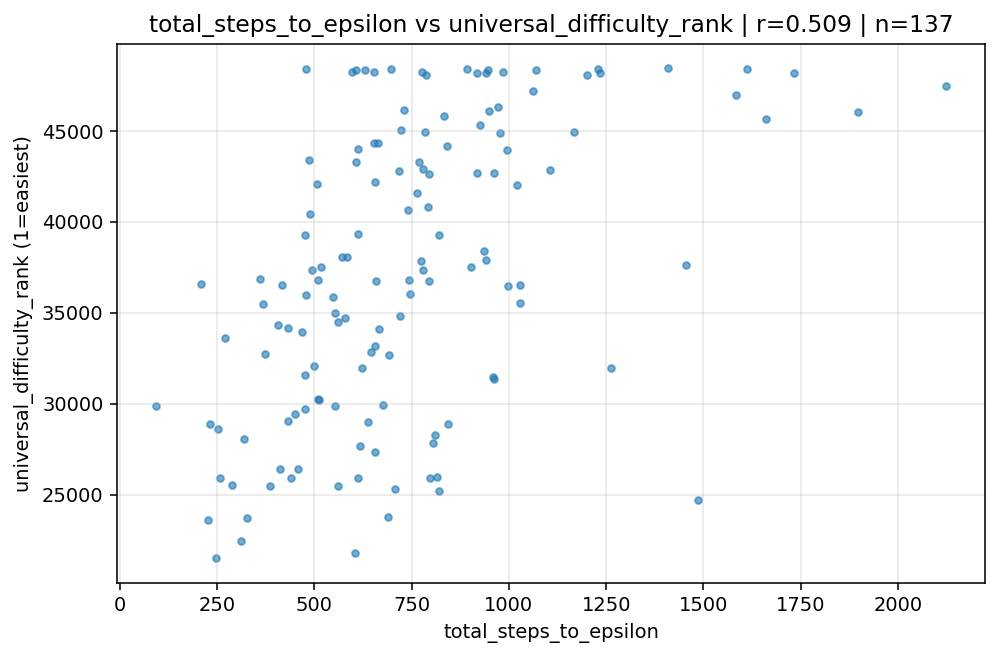

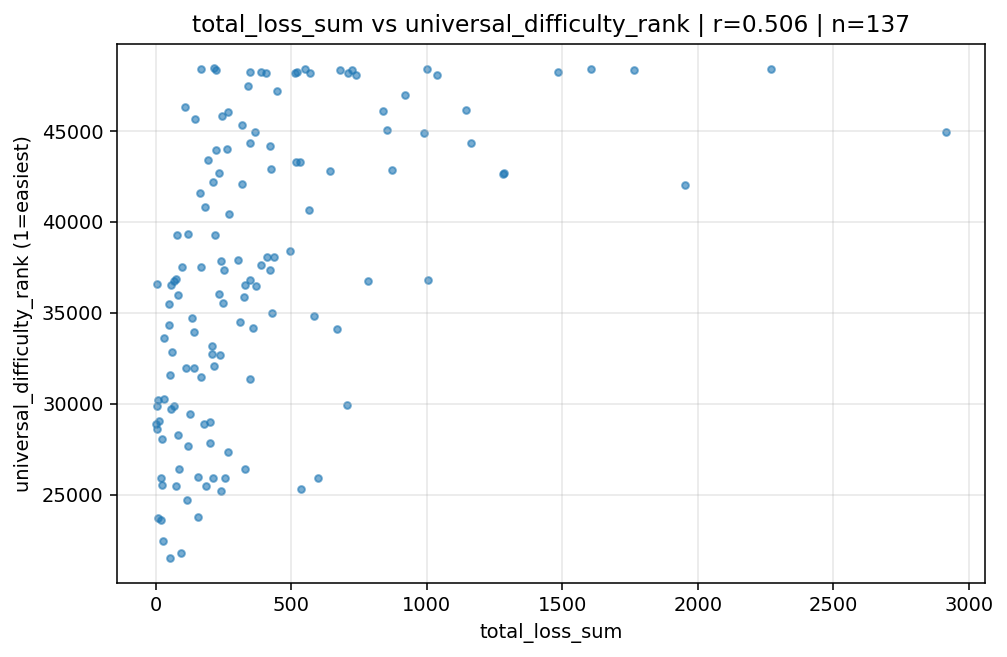

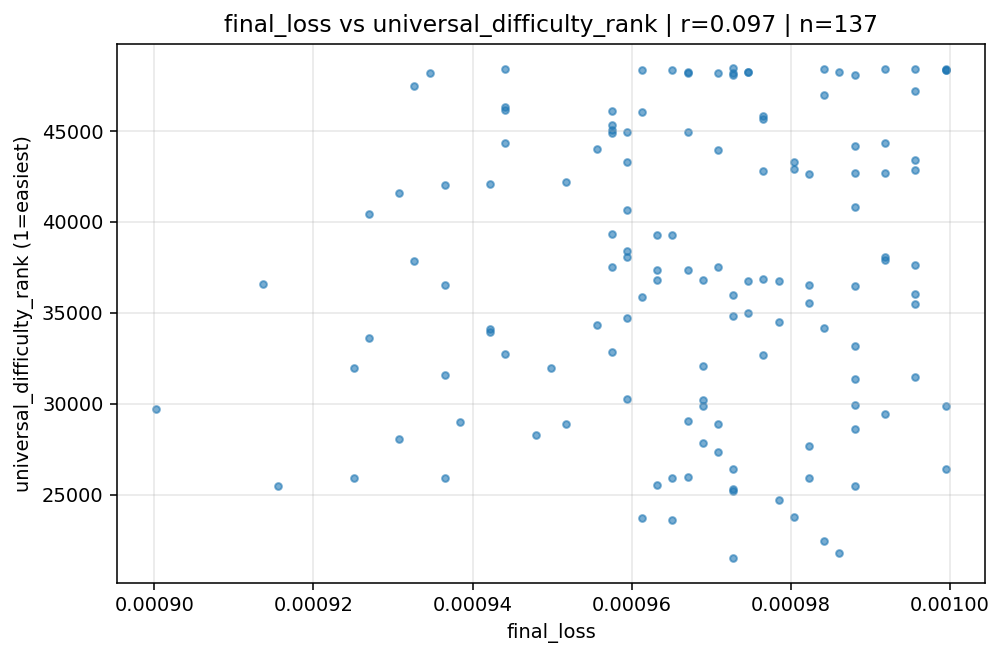

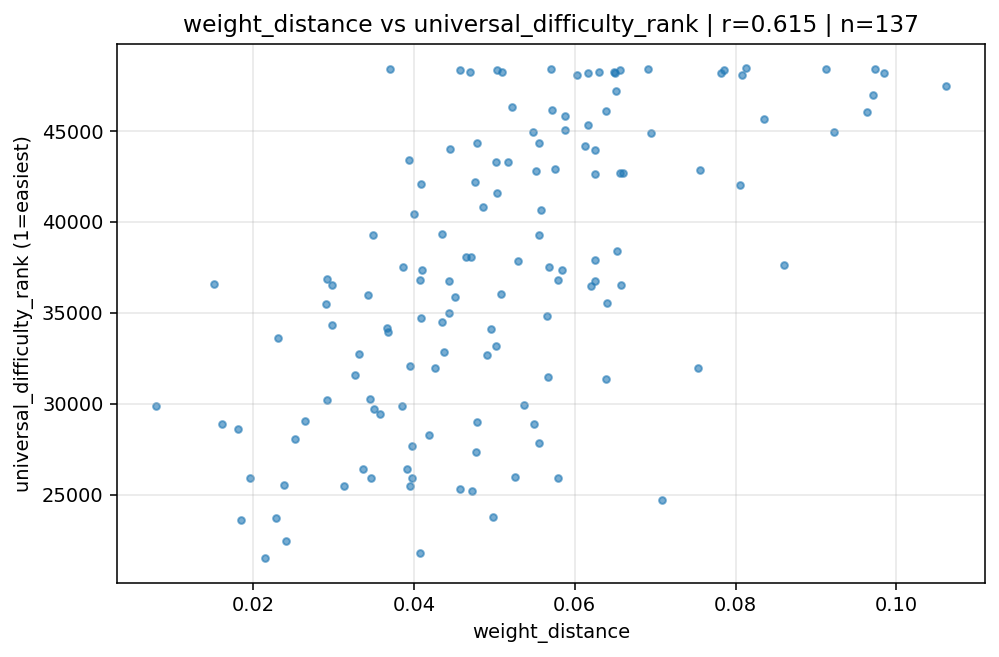

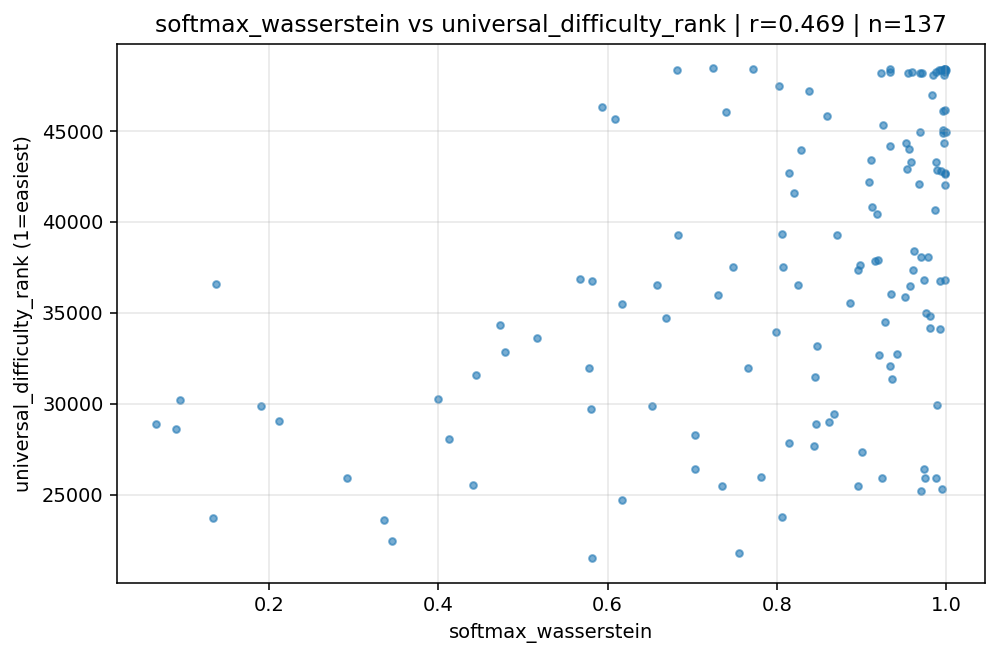

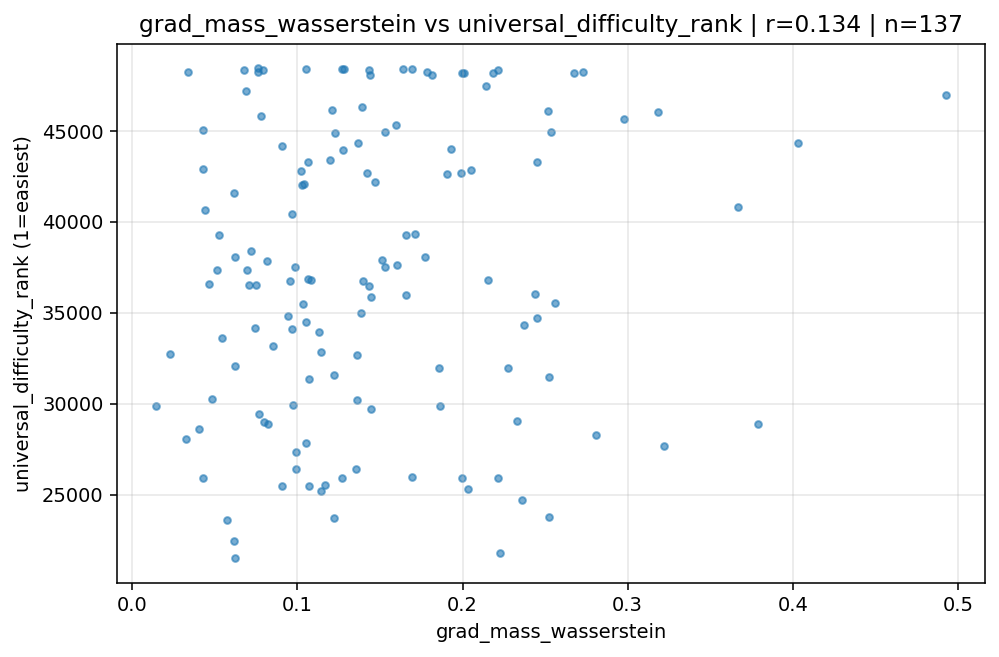

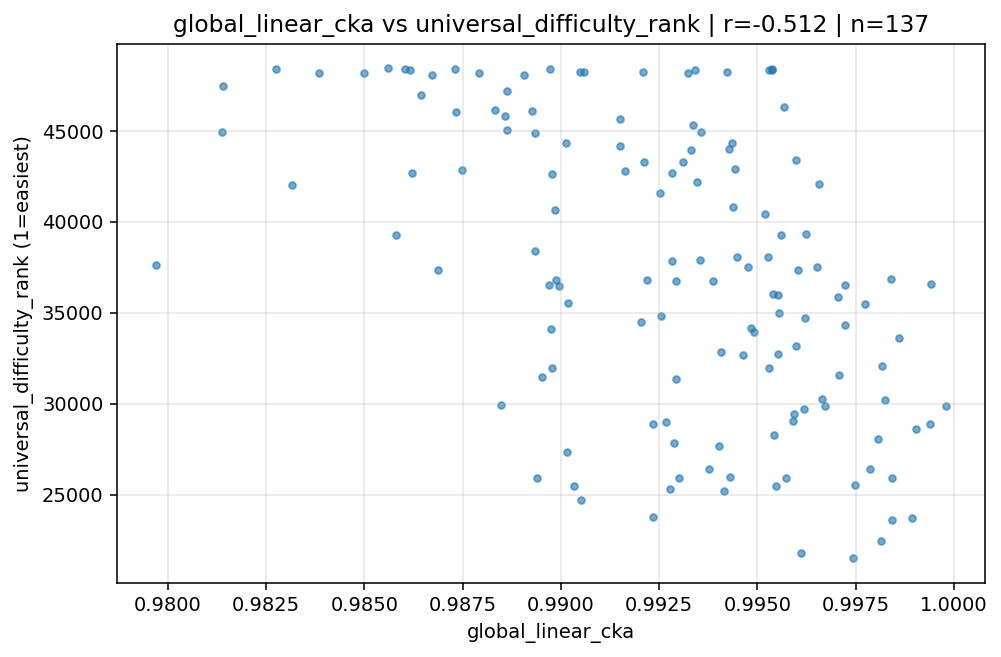

Saved plots and correlations to: q:\Projects\BMM_school\Universal_learning\Programming\training_gradient_evaluator_single_loss\outputs_lr_0.0001\aggregated_across_models


In [109]:
# Plot metrics vs universal_difficulty_rank with correlations in titles

from scipy.stats import pearsonr

def safe_corr(x: np.ndarray, y: np.ndarray) -> float:
	try:
		if len(x) < 2 or len(y) < 2:
			return float('nan')
		if np.all(np.isfinite(x)) and np.all(np.isfinite(y)) and np.std(x) > 0 and np.std(y) > 0:
			r, _ = pearsonr(x, y)
			return float(r)
		return float('nan')
	except Exception:
		return float('nan')

plots = []
rank = agg_df[ID_COL].to_numpy()

for metric in METRIC_COLS:
	if metric not in agg_df.columns:
		continue
	y = agg_df[metric].to_numpy()
	mask = np.isfinite(rank) & np.isfinite(y)
	xp = agg_df.loc[mask, metric].to_numpy()
	rp = agg_df.loc[mask, ID_COL].to_numpy()
	corr = safe_corr(xp, rp)
	plt.figure(figsize=(8, 5))
	plt.scatter(agg_df[metric], agg_df[ID_COL], s=12, alpha=0.6)
	plt.xlabel(metric)
	plt.ylabel("universal_difficulty_rank (1=easiest)")
	title = f"{metric} vs universal_difficulty_rank | r={corr:.3f} | n={np.sum(mask)}"
	plt.title(title)
	plt.grid(True, alpha=0.3)
	out_path = os.path.join(OUT_DIR, f"{metric}_vs_universal_difficulty_rank.png")
	plt.savefig(out_path, bbox_inches='tight')
	plt.show()
	plots.append((metric, out_path, corr))

# Save correlations JSON
corr_json = {m: float(c) if (c is not None and np.isfinite(c)) else None for m, _, c in plots}
with open(os.path.join(OUT_DIR, "aggregated_correlations.json"), 'w', encoding='utf-8') as f:
	json.dump({"num_points": int(len(agg_df)), "correlations": corr_json}, f, indent=2)

print("Saved plots and correlations to:", OUT_DIR)
